<a href="https://colab.research.google.com/github/JPAmewu/My_Capstone_1_Imperial/blob/main/Week_3_Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np

os.makedirs("week_3_data", exist_ok=True)

week_2_inputs = {
    1: [0.536429, 0.835362],
    2: [0.978752, 0.932731],
    3: [0.657452, 0.998464, 0.817253],
    4: [0.006280, 0.281840, 0.932013, 0.960202],
    5: [0.255841, 0.841692, 0.888984, 0.860260],
    6: [0.433654, 0.486678, 0.282753, 0.972905, 0.323321],
    7: [0.243848, 0.900100, 0.696978, 0.193630, 0.374149, 0.826324],
    8: [0.163160, 0.184786, 0.152644, 0.083802, 0.999322, 0.544113, 0.184124, 0.123846]
}

week_2_outputs = {
    1: 1.674933466363685e-36,
    2: 0.022666631114895516,
    3: -0.08987474979637637,
    4: -31.73535839431216,
    5: 1035.6341457754475,
    6: -0.8782405650300305,
    7: 0.308765180253091,
    8: 9.9399041910574
}

print('week_2_data ready')



week_2_data ready


In [ ]:
week_1_inputs = {
    1: [0.375440, 0.950714],
    2: [0.375440, 0.950714],
    3: [0.444444, 0.666666, 0.333333],
    4: [0.555555, 0.444444, 0.222222, 0.111111],
    5: [0.224189, 0.846480, 0.879484, 0.878515],
    6: [0.728186, 0.154693, 0.732552, 0.693997, 0.564013],
    7: [0.045091, 0.528666, 0.329265, 0.105350, 0.434667, 0.641164],
    8: [0.273673, 0.260400, 0.073937, 0.078562, 0.862321, 0.230729]
}

week_1_outputs = {
    1: -1.560646704467178e-117,
    2: -0.03182956281754251,
    3: -0.04090761844941528,
    4: -8.727516493155957,
    5: 1088.8535114737463,
    6: -1.1520351120911565,
    7: 1.0510148516295004,
    8: 9.8157087929671
}

print("week_1_data ready")

week_1_data ready


In [ ]:
import zipfile
import numpy as np
import os
import shutil

if os.path.exists("week_3_data"):
    shutil.rmtree("week_3_data")

with zipfile.ZipFile("initial_data.zip", "r") as zip_ref:
    zip_ref.extractall("initial_data")

os.makedirs("week_3_data", exist_ok=True)

def fix_dimension(values, dim):
    values = list(values)
    if len(values) < dim:
        values = values + [0.5] * (dim - len(values))
    if len(values) > dim:
        values = values[:dim]
    return np.array(values).reshape(1, dim)

for fn in range(1, 9):

    X_initial = np.load(f"initial_data/initial_data_1/function_{fn}/initial_inputs.npy")
    y_initial = np.load(f"initial_data/initial_data_1/function_{fn}/initial_outputs.npy")

    dim = X_initial.shape[1]

    x1 = fix_dimension(week_1_inputs[fn], dim)
    x2 = fix_dimension(week_2_inputs[fn], dim)

    y1 = week_1_outputs[fn]
    y2 = week_2_outputs[fn]

    X_new = np.vstack([X_initial, x1, x2])
    y_new = np.append(y_initial, [y1, y2])

    np.save(f"week_3_data/function_{fn}_inputs.npy", X_new)
    np.save(f"week_3_data/function_{fn}_outputs.npy", y_new)

print("Week 3 cumulative data created successfully")

Week 3 cumulative data created successfully



FUNCTION 1
Input shape: (12, 2)
Output shape: (12,)
Number of queries: 12
Best output: 7.710875114502849e-16
Best query point:
[0.73102363 0.73299988]


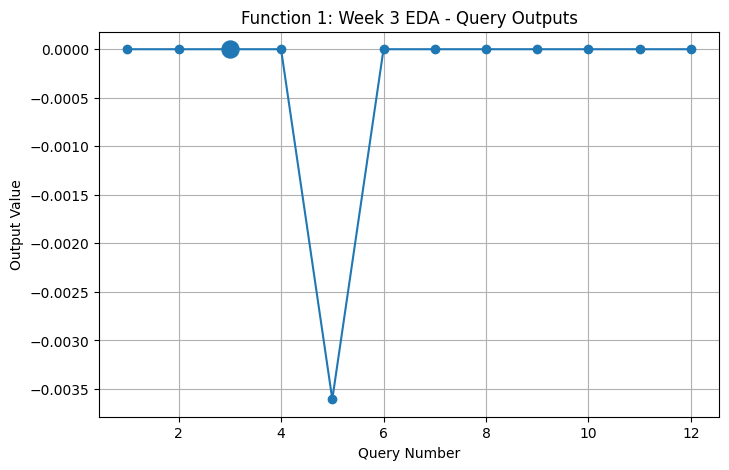


FUNCTION 2
Input shape: (12, 2)
Output shape: (12,)
Number of queries: 12
Best output: 0.6112052157614438
Best query point:
[0.70263656 0.9265642 ]


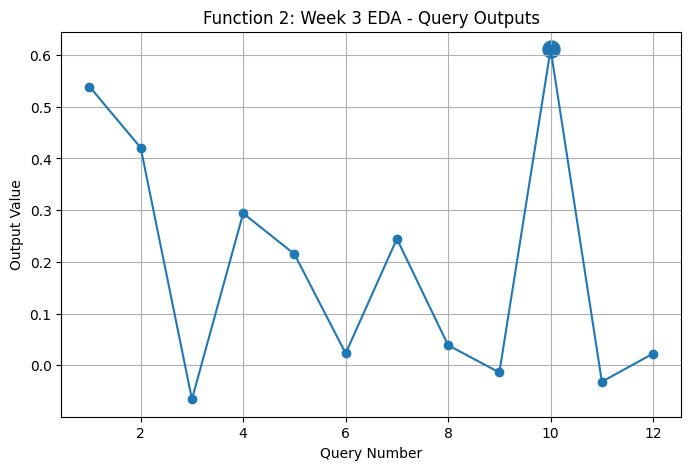


FUNCTION 3
Input shape: (17, 3)
Output shape: (17,)
Number of queries: 17
Best output: -0.034835313350078584
Best query point:
[0.49258141 0.61159319 0.34017639]


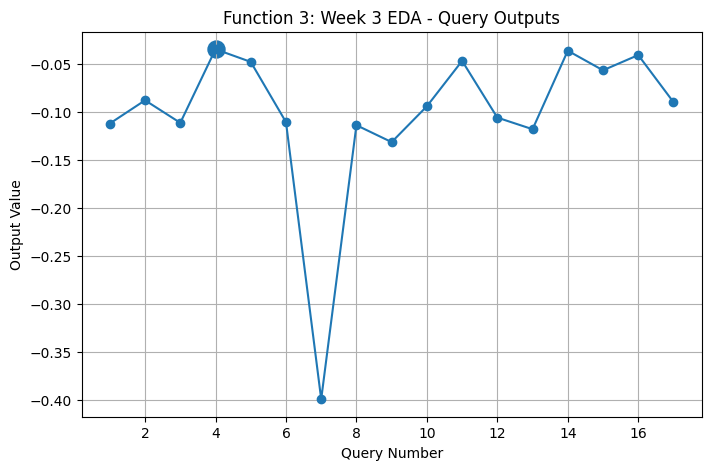


FUNCTION 4
Input shape: (32, 4)
Output shape: (32,)
Number of queries: 32
Best output: -4.025542281908162
Best query point:
[0.57776561 0.42877174 0.42582587 0.24900741]


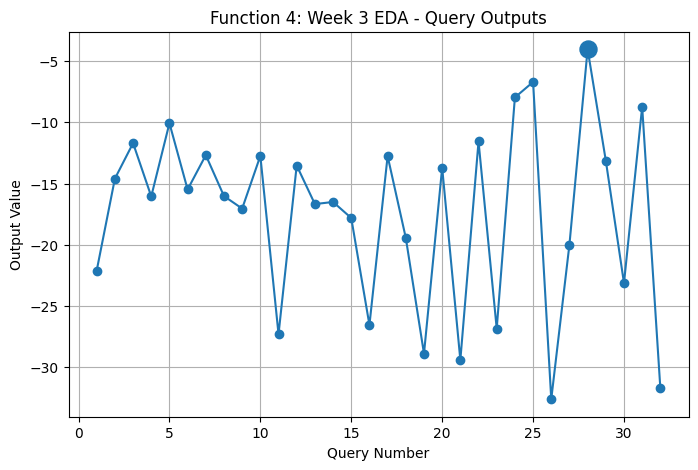


FUNCTION 5
Input shape: (22, 4)
Output shape: (22,)
Number of queries: 22
Best output: 1088.8596181962705
Best query point:
[0.22418902 0.84648049 0.87948418 0.87851568]


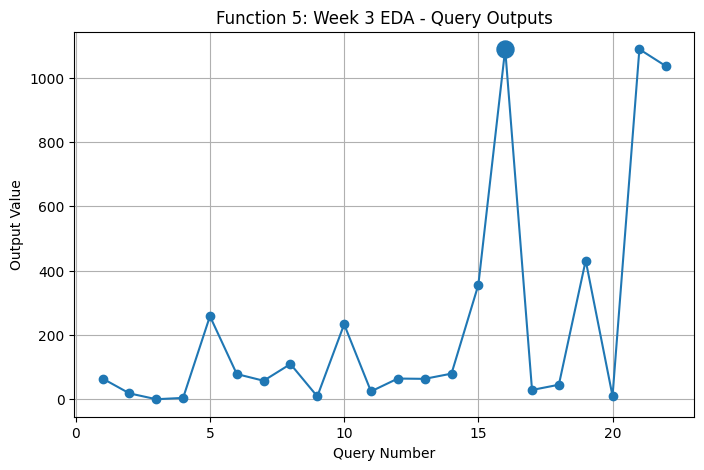


FUNCTION 6
Input shape: (22, 5)
Output shape: (22,)
Number of queries: 22
Best output: -0.7142649478202404
Best query point:
[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]


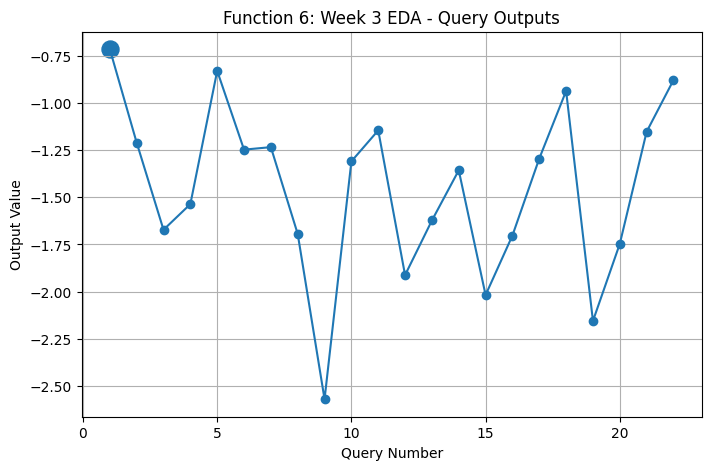


FUNCTION 7
Input shape: (32, 6)
Output shape: (32,)
Number of queries: 32
Best output: 1.3649683044991994
Best query point:
[0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]


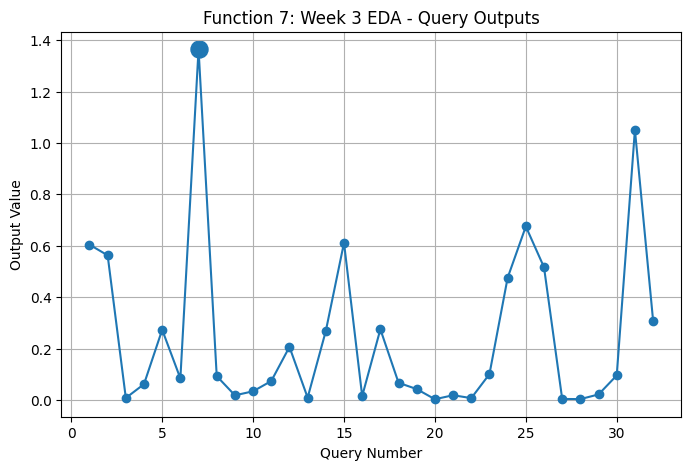


FUNCTION 8
Input shape: (42, 8)
Output shape: (42,)
Number of queries: 42
Best output: 9.9399041910574
Best query point:
[0.16316  0.184786 0.152644 0.083802 0.999322 0.544113 0.184124 0.123846]


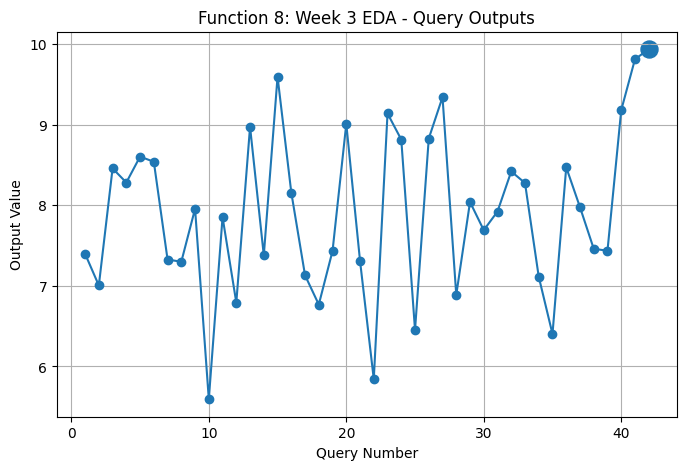

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

for i in range(1, 9):

    X = np.load(f"week_3_data/function_{i}_inputs.npy")
    y = np.load(f"week_3_data/function_{i}_outputs.npy")

    best_idx = np.argmax(y)

    print("\n" + "="*50)
    print(f"FUNCTION {i}")
    print("="*50)
    print("Input shape:", X.shape)
    print("Output shape:", y.shape)
    print("Number of queries:", len(y))
    print("Best output:", np.max(y))
    print("Best query point:")
    print(X[best_idx])

    plt.figure(figsize=(8,5))
    plt.plot(range(1, len(y)+1), y, marker="o")
    plt.scatter(best_idx + 1, y[best_idx], s=150)

    plt.title(f"Function {i}: Week 3 EDA - Query Outputs")
    plt.xlabel("Query Number")
    plt.ylabel("Output Value")
    plt.grid(True)
    plt.show()

In [ ]:
# Strategy used for each function in Week 3

import numpy as np

strategy = {
    1: "Bayesian Optimisation",
    2: "Bayesian Optimisation",
    3: "Bayesian Optimisation",
    4: "Bayesian Optimisation",
    5: "Manual Reasoning",
    6: "Bayesian Optimisation",
    7: "Bayesian Optimisation",
    8: "Bayesian Optimisation"
}

for i in range(1, 9):

    X = np.load(f"week_3_data/function_{i}_inputs.npy")
    y = np.load(f"week_3_data/function_{i}_outputs.npy")

    best_idx = np.argmax(y)

    print("\n" + "="*60)
    print(f"FUNCTION {i}")
    print(f"Strategy: {strategy[i]}")
    print("="*60)

    print("Number of Queries:", len(y))
    print("Best Output:", y[best_idx])
    print("Best Input Point:")
    print(X[best_idx])


FUNCTION 1
Strategy: Bayesian Optimisation
Number of Queries: 12
Best Output: 7.710875114502849e-16
Best Input Point:
[0.73102363 0.73299988]

FUNCTION 2
Strategy: Bayesian Optimisation
Number of Queries: 12
Best Output: 0.6112052157614438
Best Input Point:
[0.70263656 0.9265642 ]

FUNCTION 3
Strategy: Bayesian Optimisation
Number of Queries: 17
Best Output: -0.034835313350078584
Best Input Point:
[0.49258141 0.61159319 0.34017639]

FUNCTION 4
Strategy: Bayesian Optimisation
Number of Queries: 32
Best Output: -4.025542281908162
Best Input Point:
[0.57776561 0.42877174 0.42582587 0.24900741]

FUNCTION 5
Strategy: Manual Reasoning
Number of Queries: 22
Best Output: 1088.8596181962705
Best Input Point:
[0.22418902 0.84648049 0.87948418 0.87851568]

FUNCTION 6
Strategy: Bayesian Optimisation
Number of Queries: 22
Best Output: -0.7142649478202404
Best Input Point:
[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]

FUNCTION 7
Strategy: Bayesian Optimisation
Number of Queries: 32
Best


Function 1
Best Query Point: [0.73102363 0.73299988]
Best Output: 7.710875114502849e-16


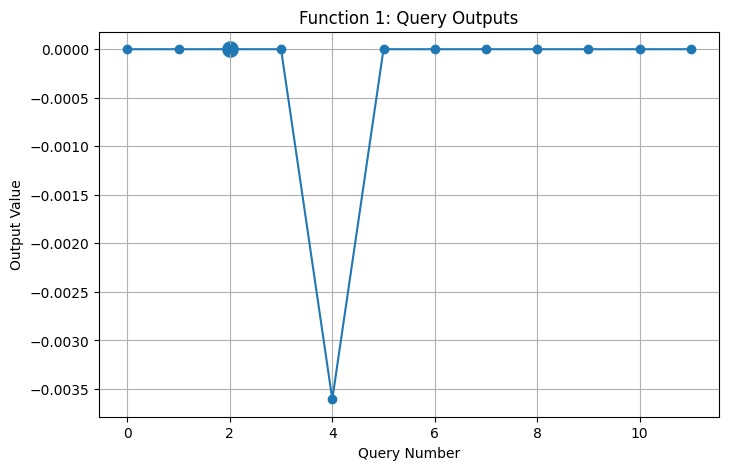


Function 2
Best Query Point: [0.70263656 0.9265642 ]
Best Output: 0.6112052157614438


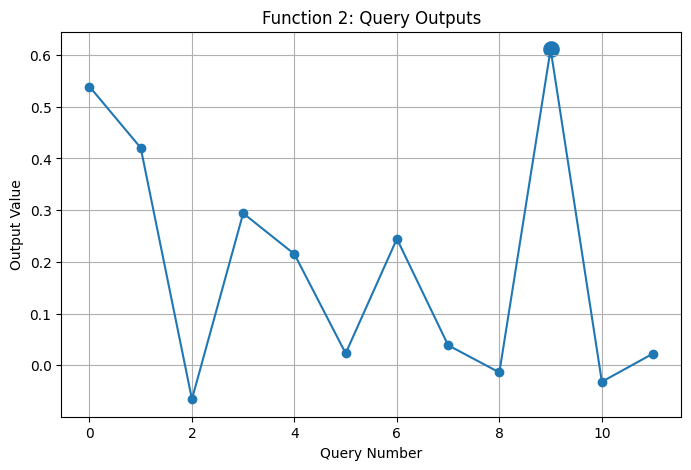


Function 3
Best Query Point: [0.49258141 0.61159319 0.34017639]
Best Output: -0.034835313350078584


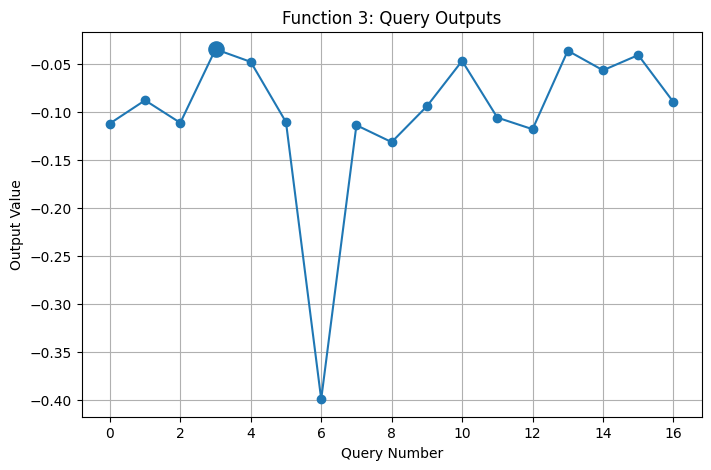


Function 4
Best Query Point: [0.57776561 0.42877174 0.42582587 0.24900741]
Best Output: -4.025542281908162


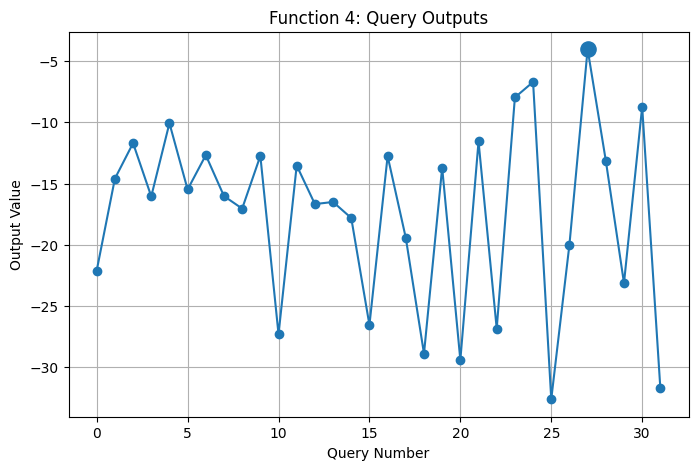


Function 5
Best Query Point: [0.22418902 0.84648049 0.87948418 0.87851568]
Best Output: 1088.8596181962705


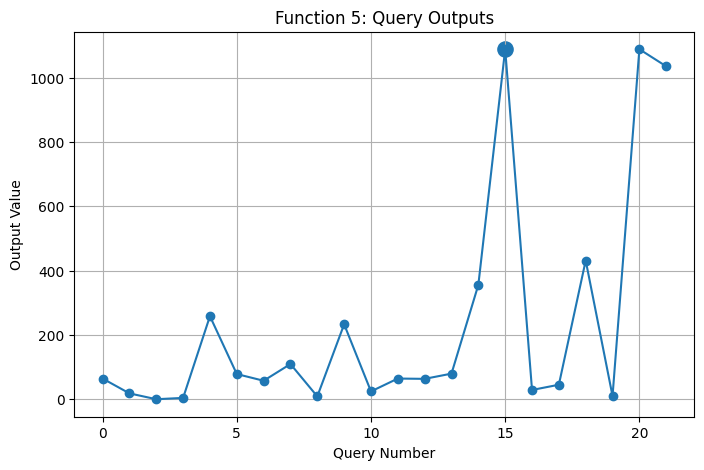


Function 6
Best Query Point: [0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
Best Output: -0.7142649478202404


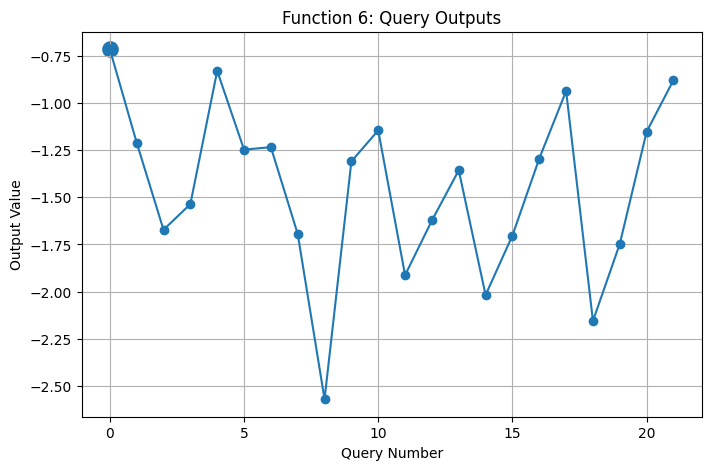


Function 7
Best Query Point: [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
Best Output: 1.3649683044991994


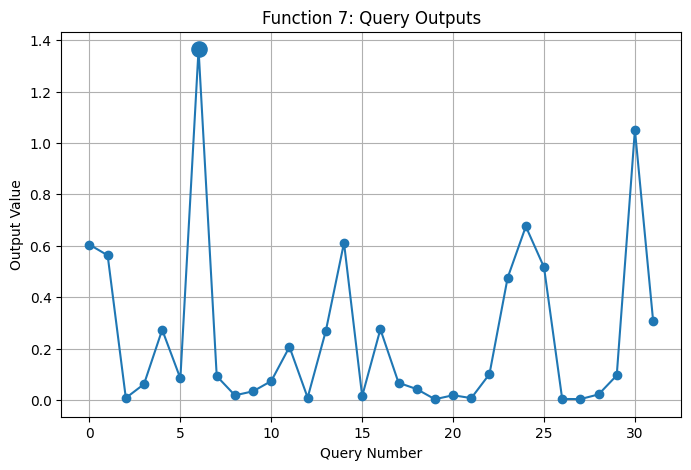


Function 8
Best Query Point: [0.16316  0.184786 0.152644 0.083802 0.999322 0.544113 0.184124 0.123846]
Best Output: 9.9399041910574


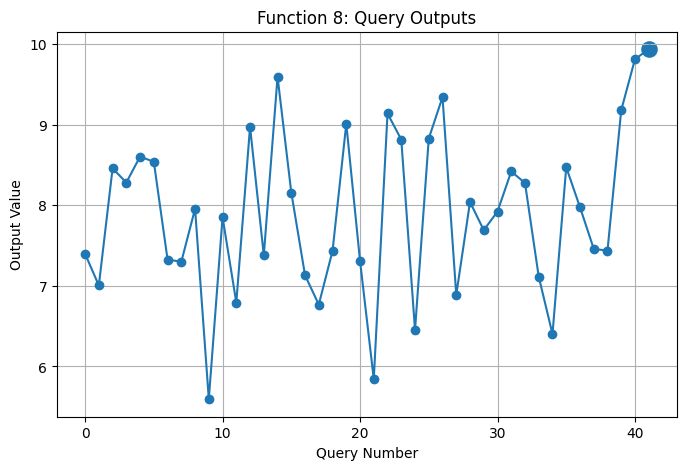

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

for i in range(1, 9):

    X = np.load(f"week_3_data/function_{i}_inputs.npy")
    y = np.load(f"week_3_data/function_{i}_outputs.npy")

    best_idx = np.argmax(y)

    plt.figure(figsize=(8,5))
    plt.plot(range(len(y)), y, marker='o')
    plt.scatter(best_idx, y[best_idx], s=120)

    print(f"\nFunction {i}")
    print("Best Query Point:", X[best_idx])
    print("Best Output:", y[best_idx])

    plt.title(f"Function {i}: Query Outputs")
    plt.xlabel("Query Number")
    plt.ylabel("Output Value")
    plt.grid(True)
    plt.show()

In [ ]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

np.random.seed(42)

def manual_reasoning_query(X, y):
    best_idx = np.argmax(y)
    best_x = X[best_idx]

    noise = np.random.normal(0, 0.05, size=best_x.shape)
    new_x = np.clip(best_x + noise, 0, 1)

    return new_x


def bayesian_optimisation_query(X, y, kappa, n_candidates=10000):

    dim = X.shape[1]

    kernel = (
        ConstantKernel(1.0, (1e-3, 1e3))
        * RBF(length_scale=np.ones(dim),
              length_scale_bounds=(1e-2, 1e2))
        + WhiteKernel(noise_level=1e-5)
    )

    gp = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=42
    )

    gp.fit(X, y)

    X_candidates = np.random.uniform(
        0, 1,
        size=(n_candidates, dim)
    )

    mu, sigma = gp.predict(
        X_candidates,
        return_std=True
    )

    # UCB Acquisition Function
    acquisition = mu + kappa * sigma

    best_idx = np.argmax(acquisition)

    return X_candidates[best_idx]


kappa_values = {
    1: 5,
    2: 5,
    3: 5,
    4: 5,
    6: 5,
    7: 2,
    8: 5
}

# Create empty dictionary to store Week 2 query points
submission_queries = {}

for i in range(1, 9):

    X = np.load(f"week_3_data/function_{i}_inputs.npy")
    y = np.load(f"week_3_data/function_{i}_outputs.npy")

    if i == 5:

        next_query = manual_reasoning_query(X, y)

        print("="*70)
        print("FUNCTION 5")
        print("Method: Manual Reasoning")
        print("QUERY TO SUBMIT:")
        print(next_query)

    else:

        kappa = kappa_values[i]

        next_query = bayesian_optimisation_query(
            X,
            y,
            kappa=kappa
        )
        print("="*70)
        print(f"FUNCTION {i}")
        print("Method: Bayesian Optimisation")
        print(f"Kappa Used = {kappa}")
        print("QUERY TO SUBMIT:")
        print(next_query)

    submission_queries[f"function_{i}"] = next_query

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


FUNCTION 1
Method: Bayesian Optimisation
Kappa Used = 5
QUERY TO SUBMIT:
[0.61416885 0.33414302]


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


FUNCTION 2
Method: Bayesian Optimisation
Kappa Used = 5
QUERY TO SUBMIT:
[5.53667574e-06 3.25442415e-01]


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: Conv

FUNCTION 6
Method: Bayesian Optimisation
Kappa Used = 5
QUERY TO SUBMIT:
[4.95069820e-01 9.71520460e-02 6.72921103e-01 6.57199760e-06
 3.51267516e-01]


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


FUNCTION 7
Method: Bayesian Optimisation
Kappa Used = 2
QUERY TO SUBMIT:
[0.14358542 0.30255949 0.57110088 0.19453273 0.39556065 0.81579229]
FUNCTION 8
Method: Bayesian Optimisation
Kappa Used = 5
QUERY TO SUBMIT:
[0.01106064 0.89054457 0.06036561 0.91576322 0.59526314 0.44574576
 0.06832177 0.80424987]


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 7 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [ ]:
import shutil

shutil.make_archive("week_3_data", "zip", "week_3_data")
print("week_3_data.zip created")

week_3_data.zip created


In [ ]:
from google.colab import files
files.download("week_3_data.zip")

FileNotFoundError: Cannot find file: week_3_data.zip

## Week 3 performance summary

This table reports F1–F8 optimisation evidence from the confirmed dataset and diagnostics retained during the original run. Missing diagnostics are labelled **Not recorded**; no historical GP model is refitted.

In [ ]:
# Reproducible performance evidence for Week 3
import os
import numpy as np
import pandas as pd

SUMMARY_WEEK = 3
SUMMARY_DATASET_FOLDER = "week_3_data"
SUMMARY_IS_PENDING = False

summary_columns = [
    "Week", "Function", "Observation count", "Previous best",
    "New observation", "New best", "Improvement", "Fitted GP kernel",
    "Predictive std at selected query", "UCB score", "Evidence status",
]


def _find_output_file(folder, function_number):
    candidates = [
        os.path.join(folder, f"function_{function_number}_outputs.npy"),
        os.path.join(
            folder, f"function_{function_number}", "initial_outputs.npy"
        ),
    ]
    for candidate in candidates:
        if os.path.isfile(candidate):
            return candidate
    raise FileNotFoundError(
        f"No confirmed output file found for F{function_number} in {folder}."
    )


def _recorded_gp_diagnostics(function_number):
    """Return only diagnostics already retained by the notebook."""
    diagnostic = {
        "kernel": "Not recorded",
        "std": np.nan,
        "ucb": np.nan,
    }

    query_records = globals().get("all_queries")
    record = None
    if isinstance(query_records, dict):
        record = query_records.get(
            function_number,
            query_records.get(f"Function_{function_number}"),
        )
    if not isinstance(record, dict):
        candidate = globals().get(f"result_{function_number}")
        record = candidate if isinstance(candidate, dict) else None

    if isinstance(record, dict):
        kernel = record.get("fitted_kernel")
        std = record.get(
            "predicted_std_scaled",
            record.get("predicted_std", np.nan),
        )
        ucb = record.get("ucb_value", np.nan)
        if kernel is not None:
            diagnostic["kernel"] = str(kernel)
        if std is not None:
            diagnostic["std"] = float(np.asarray(std).reshape(-1)[0])
        if ucb is not None:
            diagnostic["ucb"] = float(np.asarray(ucb).reshape(-1)[0])

    gp = globals().get(f"gp_{function_number}")
    if gp is not None and hasattr(gp, "kernel_"):
        diagnostic["kernel"] = str(gp.kernel_)

    saved_std = globals().get(f"next_std_{function_number}")
    if saved_std is not None:
        diagnostic["std"] = float(np.asarray(saved_std).reshape(-1)[0])

    ucb_values = globals().get(f"ucb_{function_number}")
    selected_index = globals().get(f"next_index_{function_number}")
    if ucb_values is not None and selected_index is not None:
        diagnostic["ucb"] = float(
            np.asarray(ucb_values).reshape(-1)[int(selected_index)]
        )

    return diagnostic


performance_rows = []
for function_number in range(1, 9):
    row = {
        "Week": SUMMARY_WEEK,
        "Function": f"F{function_number}",
        "Observation count": np.nan,
        "Previous best": np.nan,
        "New observation": np.nan,
        "New best": np.nan,
        "Improvement": np.nan,
        "Fitted GP kernel": "Not recorded",
        "Predictive std at selected query": np.nan,
        "UCB score": np.nan,
        "Evidence status": (
            "Pending" if SUMMARY_IS_PENDING else "Dataset not loaded"
        ),
    }

    if not SUMMARY_IS_PENDING:
        output_file = _find_output_file(
            SUMMARY_DATASET_FOLDER, function_number
        )
        y = np.asarray(np.load(output_file), dtype=float).reshape(-1)
        if y.size == 0 or not np.isfinite(y).all():
            raise ValueError(
                f"Week {SUMMARY_WEEK}, F{function_number}: invalid outputs."
            )

        row["Observation count"] = int(y.size)
        row["New best"] = float(np.max(y))

        if SUMMARY_WEEK == 1:
            row["Evidence status"] = (
                "Confirmed initial dataset; no previous round"
            )
        elif y.size > 1:
            previous_best = float(np.max(y[:-1]))
            new_observation = float(y[-1])
            new_best = float(np.max(y))
            row.update({
                "Previous best": previous_best,
                "New observation": new_observation,
                "New best": new_best,
                "Improvement": new_best - previous_best,
                "Evidence status": "Confirmed dataset",
            })

        diagnostics = _recorded_gp_diagnostics(function_number)
        row.update({
            "Fitted GP kernel": diagnostics["kernel"],
            "Predictive std at selected query": diagnostics["std"],
            "UCB score": diagnostics["ucb"],
        })
        if (
            diagnostics["kernel"] != "Not recorded"
            or np.isfinite(diagnostics["std"])
            or np.isfinite(diagnostics["ucb"])
        ):
            row["Evidence status"] += "; recorded GP diagnostics included"

    performance_rows.append(row)

weekly_performance_summary = pd.DataFrame(
    performance_rows,
    columns=summary_columns,
)
weekly_performance_summary
